In [ ]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Localizamos la carpeta 'solution' subiendo desde el directorio de trabajo, sin
# suponer dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como
# la raíz del repositorio. Su marca es el fichero 'pyproject.toml'.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

DATA_DIR = SOLUTION_DIR / "data"
MODELS_DIR = SOLUTION_DIR / "models"
PREDICTIONS_DIR = DATA_DIR / "predictions"

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que
# se importan desde su carpeta
sys.path.insert(0, str(MODELS_DIR))

# El nombre del fichero puede llevar la fecha de generación como prefijo
data_dir = DATA_DIR / "splits"
candidates = (
    sorted(data_dir.glob("*processed_data_no_duplicates.npz"))
    + sorted(data_dir.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

In [ ]:
y_test = data["y_test"]
y_ivar_test = data["y_ivar_test"]
X_id_test= data["X_id_test"]

In [ ]:
from iSpec_functions import load_gaia_table

# Cargamos la tabla de Gaia guardada en local
gaia_data_df = load_gaia_table()

gaia_data_df_no_dup = gaia_data_df[
    gaia_data_df["source_id"].isin(X_id_test)
].copy()

bp_rp = gaia_data_df_no_dup["bp_rp"]
g_mag = gaia_data_df_no_dup["phot_g_mean_mag"]
parallax = gaia_data_df_no_dup["parallax"]

In [ ]:
import pandas as pd

from model_functions import (
    calculate_all_chi2,
    plot_hr_chi2_hexbin
)

In [ ]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from services.predictions import load_predictions

# Cada cuaderno de entrenamiento deja un `.npz` por modelo, todos con la misma
# clave 'y_pred', así que se leen de una vez en un diccionario por modelo
model_names = [
    "dense-global",
    "dense-median",
    "dense-max",
    "gru",
    "birnn",
    "birnn-attention",
    "cnn_v1",
    "cnn-v2"
]

predictions = {
    name: load_predictions(PREDICTIONS_DIR / f"{name}_predictions.npz")["y_pred"]
    for name in model_names
    if (PREDICTIONS_DIR / f"{name}_predictions.npz").is_file()
}

print("Predicciones disponibles:", list(predictions))

In [ ]:
# Chi cuadrado de cada modelo sobre el mismo conjunto de test
chi2_by_model = {
    name: calculate_all_chi2(y_test, y_pred, y_ivar_test, True)
    for name, y_pred in predictions.items()
}

# La mediana es la cifra con la que se comparan las arquitecturas en la memoria
chi2_medians = pd.DataFrame(
    [
        {"modelo": name, "chi2 mediana": float(np.median(chi2))}
        for name, chi2 in chi2_by_model.items()
    ]
).sort_values("chi2 mediana")

display(chi2_medians)

In [ ]:
# Diagrama HR coloreado por chi cuadrado, para el modelo que se quiera mirar
model_name = "dense-median"

chi_median = chi2_by_model[model_name]

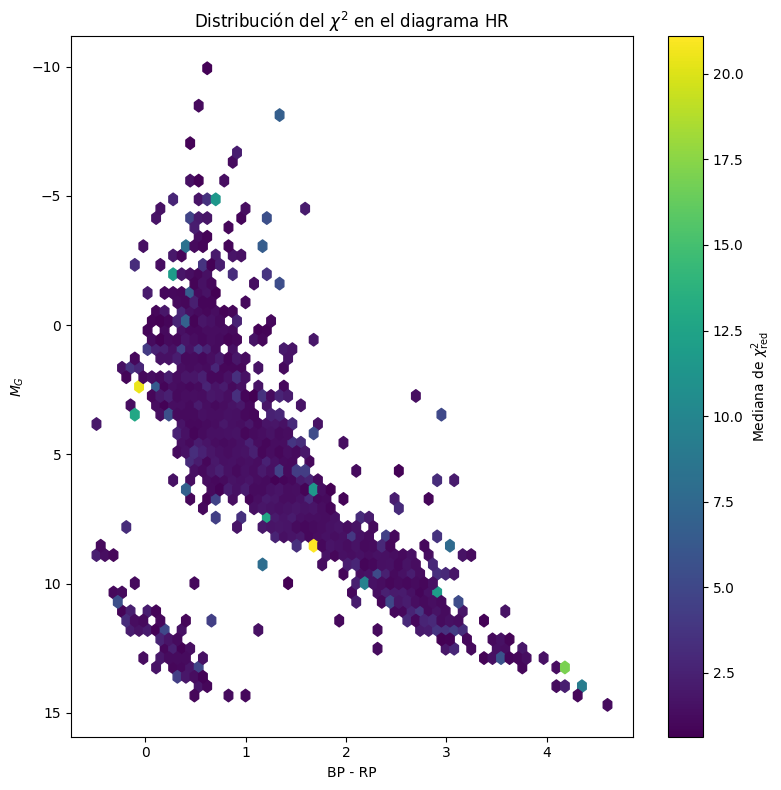

In [ ]:
plot_hr_chi2_hexbin(
    bp_rp,
    g_mag,
    parallax,
    chi_median,
    gridsize=60,
    mincnt=1,
    figsize=(8, 8)
)